# Conduct an Exploratory Data Analysis (EDA) on the dataset. Highlight the main insights and any irregularities you find, and address those anomalies appropriately!

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset
df = pd.read_csv('Credis_Score_Dataset_A.csv')

In [2]:
# 2. Fungsi Helper untuk Pembersihan Data
def robust_clean(val):
    """Menghapus karakter non-numerik dan menangani placeholder aneh."""
    if pd.isna(val): return np.nan
    s = str(val).strip()
    # Menghapus karakter selain angka, titik, dan minus
    s = re.sub(r'[^0-9.\-]', '', s)
    if s == '' or s == '-' or s == '.': return np.nan
    try:
        # Menangani nilai placeholder seperti '333333333...'
        if '333333333' in str(val): return np.nan
        return float(s)
    except:
        return np.nan

def transform_history_age(val):
    """Mengubah format 'X Years and Y Months' menjadi total bulan (integer)."""
    if pd.isna(val) or not isinstance(val, str):
        return np.nan
    try:
        parts = re.findall(r'\d+', val)
        if len(parts) == 2:
            return int(parts[0]) * 12 + int(parts[1])
        return np.nan
    except:
        return np.nan

In [3]:
# 3. Pembersihan Kolom Numerik
cols_to_clean = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
                 'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance']

for col in cols_to_clean:
    df[col] = df[col].apply(robust_clean)

In [4]:
# 4. Menangani Anomali Melalui Pembatasan Nilai Data
# Membatasi nilai agar masuk akal (menangani outliers)
df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = np.nan
df.loc[df['Num_Bank_Accounts'] < 0, 'Num_Bank_Accounts'] = 0
df.loc[df['Num_Bank_Accounts'] > 20, 'Num_Bank_Accounts'] = np.nan
df.loc[df['Num_Credit_Card'] > 20, 'Num_Credit_Card'] = np.nan
df.loc[df['Interest_Rate'] > 50, 'Interest_Rate'] = np.nan # Bunga > 50% dianggap anomali
df.loc[df['Num_of_Loan'] < 0, 'Num_of_Loan'] = 0
df.loc[df['Num_of_Loan'] > 15, 'Num_of_Loan'] = np.nan
df.loc[df['Num_of_Delayed_Payment'] < 0, 'Num_of_Delayed_Payment'] = 0
df.loc[df['Num_of_Delayed_Payment'] > 30, 'Num_of_Delayed_Payment'] = np.nan
df.loc[df['Num_Credit_Inquiries'] > 25, 'Num_Credit_Inquiries'] = np.nan
df.loc[df['Delay_from_due_date'] < 0, 'Delay_from_due_date'] = 0

# Transformasi Umur Kredit
df['Credit_History_Months'] = df['Credit_History_Age'].apply(transform_history_age)

In [5]:
# 5. Pembersihan Kolom Kategorikal
df['Occupation'] = df['Occupation'].replace('_______', 'Unknown')
# Menghapus simbol aneh di Payment_Behaviour
df['Payment_Behaviour'] = df['Payment_Behaviour'].apply(
    lambda x: 'Unknown' if (not isinstance(x, str) or any(c in x for c in '!@#$%^&*')) else x
)

In [6]:
# 6. Imputasi Nilai yang Hilang (Missing Values)
# Mengisi nilai numerik dengan median
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Mengisi nilai kategorikal dengan mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      50000 non-null  object 
 4   Age                       50000 non-null  float64
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  float64
 8   Monthly_Inhand_Salary     50000 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  float64
 10  Num_Credit_Card           50000 non-null  float64
 11  Interest_Rate             50000 non-null  float64
 12  Num_of_Loan               50000 non-null  float64
 13  Type_of_Loan              50000 non-null  object 
 14  Delay_

/tmp/ipython-input-3297036194.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Credit_Score', data=df, palette='viridis', order=['Poor', 'Standard', 'Good'])


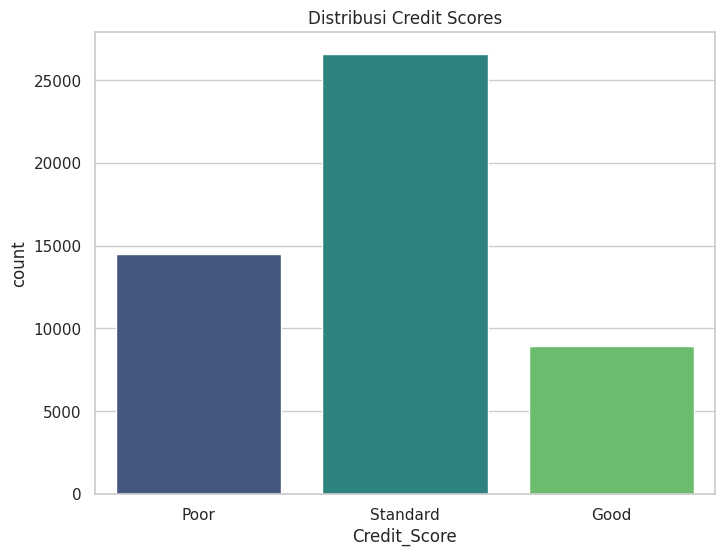

In [8]:
# 7. Visualisasi (EDA)
sns.set(style="whitegrid")

# Plot Distribusi Credit Score
plt.figure(figsize=(8, 6))
sns.countplot(x='Credit_Score', data=df, palette='viridis', order=['Poor', 'Standard', 'Good'])
plt.title('Distribusi Credit Scores')
plt.show()

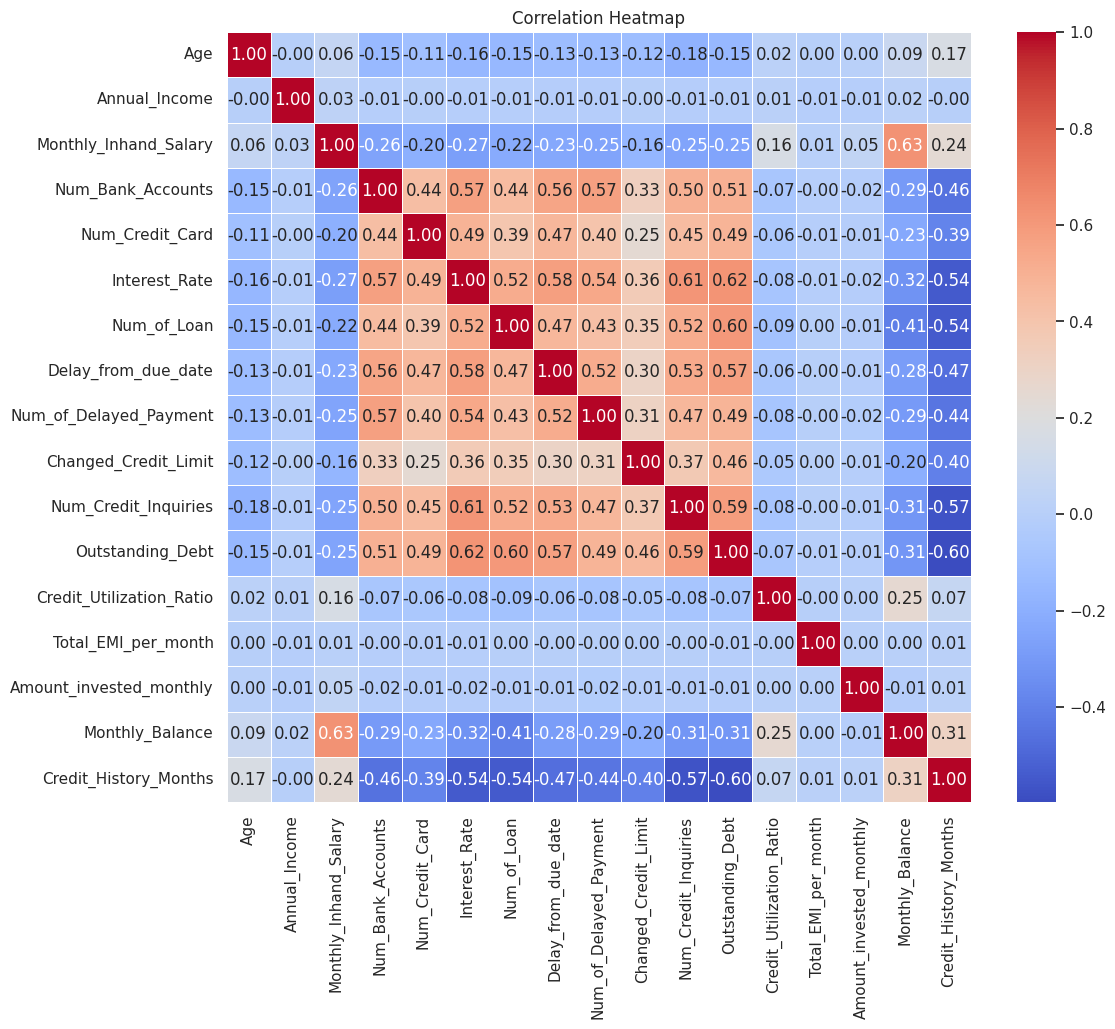

In [9]:
# Heatmap Korelasi
plt.figure(figsize=(12, 10))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

/tmp/ipython-input-2499246663.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Credit_Score', y='Outstanding_Debt', data=df, palette='Set3', order=['Poor', 'Standard', 'Good'])


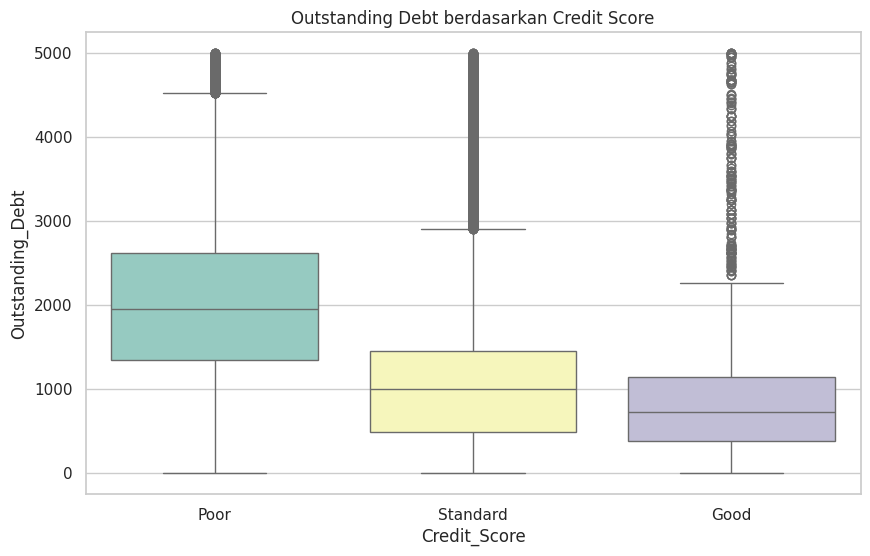

In [10]:
# Boxplot Debt vs Credit Score
plt.figure(figsize=(10, 6))
sns.boxplot(x='Credit_Score', y='Outstanding_Debt', data=df, palette='Set3', order=['Poor', 'Standard', 'Good'])
plt.title('Outstanding Debt berdasarkan Credit Score')
plt.show()

1. Irregularities (Anomali) yang Ditemukan
* Nilai numerik tidak valid / tidak masuk akal
* Placeholder dan format tidak konsisten
* Missing values (nilai hilang)


2. Penanganan Anomali (How anomalies are addressed)
* Robust numeric cleaning
* Pembatasan nilai ekstrem (logical capping)
* Transformasi fitur
* Imputasi missing values

3. Main Insights dari EDA
* Distribusi Credit Score : Mayoritas data berada pada kategori Standard. Good dan Poor muncul dalam proporsi lebih kecil
* Korelasi antar variabel numerik : Beberapa variabel keuangan (misalnya Outstanding_Debt, Interest_Rate, dan Delay_from_due_date) menunjukkan korelasi dengan variabel lain. Tidak ditemukan korelasi ekstrem yang mengindikasikan multikolinearitas parah
* Outstanding Debt vs Credit Score : Kredit Poor cenderung memiliki utang yang lebih tinggi dan lebih bervariasi. Kredit Good menunjukkan distribusi utang yang lebih terkendali

In [11]:
# 8. Simpan Data Bersih
df.to_csv('Cleaned_Credit_Score_Data.csv', index=False)
print("Pembersihan selesai. Data disimpan sebagai 'Cleaned_Credit_Score_Data.csv'")

Pembersihan selesai. Data disimpan sebagai 'Cleaned_Credit_Score_Data.csv'


# Train both Random Forest and XGBoost models, tune at least three hyperparameters for each using a search space of three or more values, and assess performance on an independent test set!

In [12]:
# MODEL TRAINING & HYPERPARAMETER TUNING

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# 1. LOAD CLEAN DATA
df = pd.read_csv("Cleaned_Credit_Score_Data.csv")

In [13]:
# 2. ENCODE CATEGORICAL VARIABLES
cat_cols = df.select_dtypes(include="object").columns

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [14]:
# 3. TRAIN-TEST SPLIT (INDEPENDENT TEST SET)
X = df.drop(columns="Credit_Score")
y = df["Credit_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
# 4. RANDOM FOREST MODEL + HYPERPARAMETER TUNING

rf = RandomForestClassifier(random_state=42)

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

In [16]:
# Random Forest EVALUATION
rf_pred = best_rf.predict(X_test)

print("===== RANDOM FOREST RESULTS =====")
print("Best Parameters:", rf_grid.best_params_)
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, average="weighted"))
print("Recall:", recall_score(y_test, rf_pred, average="weighted"))
print("F1 Score:", f1_score(y_test, rf_pred, average="weighted"))
print(classification_report(y_test, rf_pred))

===== RANDOM FOREST RESULTS =====
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Accuracy: 0.7654
Precision: 0.7651602465020645
Recall: 0.7654
F1 Score: 0.7651620442986593
              precision    recall  f1-score   support

           0       0.70      0.69      0.69      1783
           1       0.78      0.75      0.76      2900
           2       0.78      0.80      0.79      5317

    accuracy                           0.77     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.77      0.77      0.77     10000



In [ ]:
# 5. XGBOOST MODEL + HYPERPARAMETER TUNING

xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.01, 0.1, 0.3]
}

xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_


In [18]:
# XGBOOST EVALUATION
xgb_pred = best_xgb.predict(X_test)

print("\n===== XGBOOST RESULTS =====")
print("Best Parameters:", xgb_grid.best_params_)
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred, average="weighted"))
print("Recall:", recall_score(y_test, xgb_pred, average="weighted"))
print("F1 Score:", f1_score(y_test, xgb_pred, average="weighted"))
print(classification_report(y_test, xgb_pred))


===== XGBOOST RESULTS =====
Best Parameters: {'learning_rate': 0.3, 'max_depth': 10, 'n_estimators': 300}
Accuracy: 0.7739
Precision: 0.773335147765468
Recall: 0.7739
F1 Score: 0.7733013544134804
              precision    recall  f1-score   support

           0       0.73      0.68      0.70      1783
           1       0.79      0.76      0.77      2900
           2       0.78      0.81      0.80      5317

    accuracy                           0.77     10000
   macro avg       0.76      0.75      0.76     10000
weighted avg       0.77      0.77      0.77     10000



Dua model klasifikasi, yaitu Random Forest dan XGBoost, dilatih untuk memprediksi Credit_Score menggunakan data yang telah dibersihkan dan dibagi menjadi data latih (80%) serta data uji (20%). Sebelum pelatihan, variabel kategorikal dienkode menggunakan Label Encoding. Kedua model dioptimalkan melalui hyperparameter tuning menggunakan GridSearchCV dengan 3-fold cross-validation, masing-masing dengan minimal tiga hyperparameter dan beberapa nilai pencarian. Pemilihan model terbaik didasarkan pada weighted F1-score untuk mengakomodasi ketidakseimbangan kelas. Model terbaik kemudian dievaluasi pada independent test set menggunakan metrik accuracy, precision, recall, dan F1-score

# Analyze the evaluation results based on at least 3 evaluation metrics and make a conclusion!

In [19]:
# MODEL EVALUATION & METRIC COMPARISON

import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [20]:
# ASSUMPTION:
# y_test   -> true labels
# rf_pred  -> Random Forest predictions
# xgb_pred -> XGBoost predictions

# RANDOM FOREST METRICS
rf_accuracy  = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average="weighted")
rf_recall    = recall_score(y_test, rf_pred, average="weighted")
rf_f1        = f1_score(y_test, rf_pred, average="weighted")

In [21]:
# XGBOOST METRICS
xgb_accuracy  = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred, average="weighted")
xgb_recall    = recall_score(y_test, xgb_pred, average="weighted")
xgb_f1        = f1_score(y_test, xgb_pred, average="weighted")

In [22]:
# METRIC COMPARISON TABLE
evaluation_results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_accuracy, xgb_accuracy],
    "Precision (Weighted)": [rf_precision, xgb_precision],
    "Recall (Weighted)": [rf_recall, xgb_recall],
    "F1-Score (Weighted)": [rf_f1, xgb_f1]
})

print("===== MODEL EVALUATION RESULTS =====")
print(evaluation_results)

===== MODEL EVALUATION RESULTS =====
           Model  Accuracy  Precision (Weighted)  Recall (Weighted)  \
0  Random Forest    0.7654              0.765160             0.7654   
1        XGBoost    0.7739              0.773335             0.7739   

   F1-Score (Weighted)  
0             0.765162  
1             0.773301  


In [23]:
best_model = evaluation_results.loc[
    evaluation_results["F1-Score (Weighted)"].idxmax(), "Model"
]

print("\nBest Model based on F1-Score:", best_model)



Best Model based on F1-Score: XGBoost


Berdasarkan hasil evaluasi model menggunakan Accuracy, Precision (Weighted), Recall (Weighted), dan F1-Score (Weighted), dapat disimpulkan bahwa XGBoost memiliki kinerja yang lebih baik dibandingkan Random Forest. XGBoost mencapai akurasi 0,7739, lebih tinggi dari Random Forest yang sebesar 0,7654, hal ini menunjukkan prediksi keseluruhan yang lebih tepat. Dari sisi precision dan recall (weighted), XGBoost juga unggul, yang berarti model ini lebih seimbang dalam meminimalkan kesalahan prediksi dan menangkap data dari seluruh kelas credit score. Nilai F1-Score (weighted) XGBoost yang tertinggi (0,7733) menegaskan bahwa model ini memberikan performa paling seimbang antara precision dan recall, sehingga XGBoost dipilih sebagai model terbaik.

# From selected best model, analyze which inputs carry the greatest importance for forecasting the target!

In [24]:
# FEATURE IMPORTANCE ANALYSIS
# Best Model: XGBoost

import pandas as pd
import matplotlib.pyplot as plt

In [25]:
# ASSUMPTION:
# best_xgb -> best XGBoost model from GridSearch
# X_train  -> training features

# GET FEATURE IMPORTANCE
feature_importance = best_xgb.feature_importances_

In [26]:
# CREATE DATAFRAME
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importance
})

In [27]:
# SORT BY IMPORTANCE
importance_df = importance_df.sort_values(
    by="Importance", ascending=False
)

print("===== FEATURE IMPORTANCE (XGBOOST) =====")
print(importance_df)

===== FEATURE IMPORTANCE (XGBOOST) =====
                     Feature  Importance
22     Payment_of_Min_Amount    0.266573
18                Credit_Mix    0.151731
19          Outstanding_Debt    0.078473
11             Interest_Rate    0.056412
10           Num_Credit_Card    0.046384
14       Delay_from_due_date    0.026293
9          Num_Bank_Accounts    0.022607
2                      Month    0.022054
16      Changed_Credit_Limit    0.021451
23       Total_EMI_per_month    0.019525
7              Annual_Income    0.018829
12               Num_of_Loan    0.018001
13              Type_of_Loan    0.018001
17      Num_Credit_Inquiries    0.017383
0                         ID    0.017198
1                Customer_ID    0.017186
8      Monthly_Inhand_Salary    0.017008
15    Num_of_Delayed_Payment    0.016904
5                        SSN    0.016469
4                        Age    0.016424
27     Credit_History_Months    0.016380
3                       Name    0.016043
25         Payme

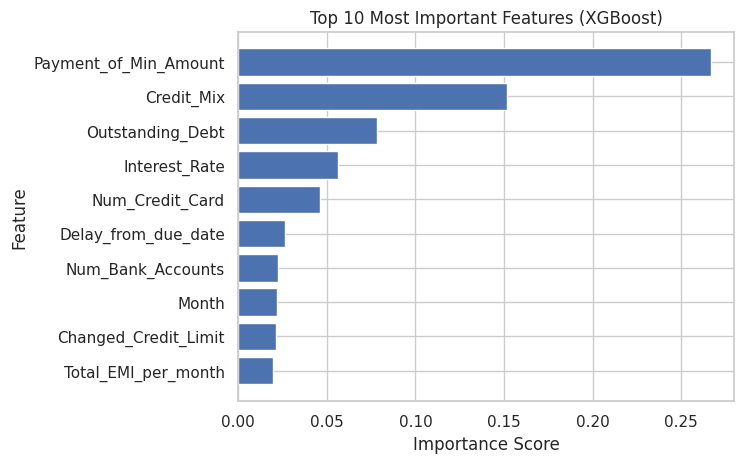

In [28]:
# VISUALIZE TOP 10 FEATURES

top_n = 10
top_features = importance_df.head(top_n)

plt.figure()
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Most Important Features (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

Berdasarkan model terbaik (XGBoost), analisis feature importance menunjukkan bahwa prediksi Credit Score paling kuat dipengaruhi oleh variabel yang merepresentasikan perilaku pembayaran dan struktur kredit. Fitur dengan pengaruh terbesar adalah Payment_of_Min_Amount, yang menandakan bahwa konsistensi dalam membayar minimal tagihan menjadi faktor paling krusial dalam menentukan kualitas kredit. Selanjutnya, Credit_Mix juga memiliki kontribusi tinggi, menunjukkan bahwa keberagaman jenis kredit mencerminkan profil kredit yang lebih sehat. Variabel finansial lain seperti Outstanding_Debt dan Interest_Rate berperan penting karena mencerminkan beban utang dan biaya kredit yang ditanggung nasabah. Sementara itu, faktor tambahan seperti jumlah kartu kredit (Num_Credit_Card), keterlambatan pembayaran (Delay_from_due_date), dan jumlah rekening bank (Num_Bank_Accounts) tetap berkontribusi, meskipun dengan pengaruh yang lebih kecil.